[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Implementation of Linear Regression using PyTorch APIs

Deep learning has witnessed an explosion over the past decade.
The sheer number of techniques, applications and algorithms by far surpasses the
progress of previous decades. 
This is due to a fortuitous combination of multiple factors,
one of which is the powerful free tools
offered by a number of open-source deep learning frameworks.
Theano and Caffe represent the first generation of such models 
that found widespread adoption.
These modern frameworks offer automatic differentiation
and the convenience of Python.
These frameworks allow us to automate and modularize
the repetitive work of implementing gradient-based learning algorithms.

In the previous notebook we relied only on
(i) tensors for data storage and linear algebra;
and (ii) automatic differentiation for calculating gradients.
In practice, because data iterators, loss functions, optimizers,
and neural network layers are so common, modern libraries implement these components for us as well.
In this notebook, **we will implement the linear regression model concisely by using the high-level API** of PyTorch.

In [21]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0);   # for reproducibility

## Defining the Model

When we implemented linear regression from scratch, we defined our model parameters explicitly and coded the calculations to produce network output
using basic linear algebra operations.
Next, we will do the same with the functionality provided by PyTorch.
In general, this allows us to focus on model architecture
rather than worrying about the implementation.
For our single neuron architecture we will use a *fully connected* layer where each of its inputs is connected to each of its outputs, and its output is computed  by means of a matrix-vector multiplication.

In PyTorch, a fully connected layer is defined in the `Linear` and `LazyLinear` classes (available since version 1.8.0). 
`LazyLinear` allows users to specify only the output dimension, while `Linear`
requires the number of inputs to a layer.
Specifying input shapes is inconvenient and may require nontrivial calculations
(such as in convolutional layers).  Thus, for simplicity, we often use "lazy" layers.


In [23]:
class LinearRegression(nn.Module):  
    """The linear regression model implemented with the PyTorch high-level API."""
    def __init__(self):
        super().__init__()
        self.net = nn.LazyLinear(1)
        # alternative is to use nn.Linear(num_in, num_out)
        # LazyLinear does not initialize the weights until the network's
        # forward function is first called
        # the setting of the seed ensures that the weights are initialized
        # in a consistent way across runs
    def forward(self, X):
        return self.net(X)        

In the `forward` method the call `self.net(X)` invokes the built-in `__call__` method of the predefined layers to compute the output.


Let's create an instance of LinearRegression:

In [24]:
model = LinearRegression()

And take a look at the instance we just created:

In [25]:
model

LinearRegression(
  (net): LazyLinear(in_features=0, out_features=1, bias=True)
)

In [26]:
model.net

LazyLinear(in_features=0, out_features=1, bias=True)

## Defining the Loss Function


The PyTorch `MSELoss` class computes the mean squared error (without the $1/2$ factor).
By default, `MSELoss` returns the average loss over examples.

In [27]:
loss_fn = nn.MSELoss()

## Defining the Optimization Algorithm


Minibatch SGD is a standard tool
for optimizing neural networks
and thus PyTorch supports it alongside a number of
variations in the `optim` module.
When we create an instance of `SGD`,
we specify the parameters to optimize over,
obtainable from our model via `model.parameters()`,
and the learning rate.

In [28]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

## Training

Expressing our model using PyTorch
requires fewer lines of code.
We did not have to allocate parameters individually,
define our loss function, or implement minibatch SGD.

Now that we have all the basic pieces in place,
the training loop itself is the same
as the one we implemented from scratch.

### The Data

We reuse the **same synthetic dataset** as in the from-scratch notebook, generated
from a known linear model

$$\mathbf{y} = \mathbf{X}\mathbf{w} + b + \boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2),$$

with ground-truth parameters $\mathbf{w} = [2.0, -3.4]^\top$ and $b = 4.2$. Because we
know the true parameters, we can check at the end how well training recovers them.
Using identical data and the same seed lets us compare this concise implementation
directly against the from-scratch one.

One subtlety worth noting: `synthetic_data` returns the targets `y` with shape
`(num_examples, 1)`, i.e. as a column vector. This matters because `nn.MSELoss` does
**not** require its two arguments to have the same shape. If the predictions (shape
`[batch, 1]`) and the targets (shape `[batch]`) differ, broadcasting silently produces
a `[batch, batch]` matrix of differences and a meaningless loss — with no error raised.
Keeping the targets as a column vector keeps the prediction and target shapes aligned.


In [29]:
# Synthetic data generator (identical to the from-scratch notebook).
# We sample features from a standard normal distribution and generate
# labels from a KNOWN linear model y = X w + b + noise.
def synthetic_data(w, b, num_examples, noise=0.1):
    """Generate y = X w + b + noise, with w a 1D tensor of true weights."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w.reshape(-1, 1)) + b
    y += torch.normal(0, noise, y.shape)
    return X, y

# Ground-truth parameters
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

torch.manual_seed(0)  # for reproducibility (matches the from-scratch notebook)
X_train, y_train = synthetic_data(true_w, true_b, num_examples=1000, noise=0.1)
X_val,   y_val   = synthetic_data(true_w, true_b, num_examples=200,  noise=0.1)

print("True w:", true_w.tolist(), " True b:", true_b)
print("X_train shape:", X_train.shape, " y_train shape:", y_train.shape)

# Create TensorDataset and DataLoader for training and validation
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)


True w: [2.0, -3.4000000953674316]  True b: 4.2
X_train shape: torch.Size([1000, 2])  y_train shape: torch.Size([1000, 1])


In [30]:
model = LinearRegression()
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

In [31]:
# training loop
epochs = 10
loss_train = []  # track training loss
loss_valid = []  # track validation loss

for epoch in range(epochs):
    # training phase
    model.train()   # set train mode (no effect here, but matters once we add dropout / batchnorm)
    loss_values = []  # track batch losses during training
    
    for batch_X, batch_y in train_dataloader:
        preds = model(batch_X)            # use __call__, not .forward(): runs hooks & lazy init
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # mean training loss for the epoch
    loss_train.append(np.mean(loss_values))
    
    # validation phase
    model.eval()    # set eval mode (again a no-op here, but good practice)
    loss_values = []  # track batch losses during validation
    
    for batch_X, batch_y in val_dataloader:
        # disable gradient calculations during validation
        with torch.no_grad():
            preds = model(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
    
    # mean validation loss for the epoch
    loss_valid.append(np.mean(loss_values))
    
    print(f"Epoch {epoch + 1}: Training Loss = {loss_train[-1]:.4f}, Validation Loss = {loss_valid[-1]:.4f}")


Epoch 1: Training Loss = 10.0354, Validation Loss = 0.8583
Epoch 2: Training Loss = 0.2161, Validation Loss = 0.0297
Epoch 3: Training Loss = 0.0134, Validation Loss = 0.0102
Epoch 4: Training Loss = 0.0094, Validation Loss = 0.0094
Epoch 5: Training Loss = 0.0094, Validation Loss = 0.0095
Epoch 6: Training Loss = 0.0093, Validation Loss = 0.0095
Epoch 7: Training Loss = 0.0093, Validation Loss = 0.0094
Epoch 8: Training Loss = 0.0093, Validation Loss = 0.0093
Epoch 9: Training Loss = 0.0093, Validation Loss = 0.0096
Epoch 10: Training Loss = 0.0093, Validation Loss = 0.0093


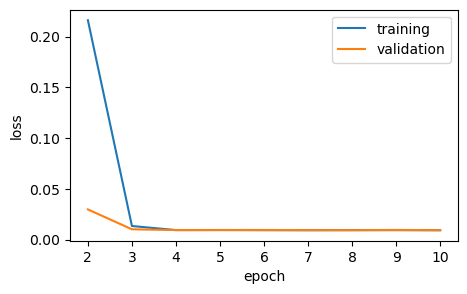

In [32]:
from matplotlib import pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(range(2, len(loss_train)+1), loss_train[1:], label='training')
plt.plot(range(2, len(loss_valid)+1), loss_valid[1:], label='validation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend();

Observe that the network now has a well-defined Linear layer:

In [33]:
model

LinearRegression(
  (net): Linear(in_features=2, out_features=1, bias=True)
)

And we can extract its weights. Because we generated the data from known
parameters, we can compare the learned values against the ground truth — the
same check we made in the from-scratch notebook:


In [34]:
w_est = model.net.weight.data.reshape(-1)
b_est = model.net.bias.data.item()

print("Estimated w:", w_est.tolist())
print("True      w:", true_w.tolist())
print("Estimated b:", b_est)
print("True      b:", true_b)

Estimated w: [1.998081088066101, -3.394582509994507]
True      w: [2.0, -3.4000000953674316]
Estimated b: 4.201335906982422
True      b: 4.2



## Ill-Conditioned Problems

Everything so far has worked smoothly: we defined a model, ran minibatch SGD, and recovered
parameters close to the ones that generated the data.  That success was partly due to the
data.  The features were independent standard normal variables, which is about the friendliest
feature matrix there is.

In this section we fit a real dataset where the features are *not* independent, introduce the
condition number as a way to measure that, and see what it does to gradient descent.

### The data

The **auto-mpg** dataset records fuel efficiency and engine characteristics for 392 car models from
the 1970s and early 1980s.  We will predict `mpg` from the numeric features.  It ships with seaborn,
so no download is needed.

In [35]:
import seaborn as sns
import pandas as pd
import numpy as np

mpg = sns.load_dataset('mpg').dropna()
FEATURES = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
print(mpg.shape)
mpg[FEATURES + ['mpg']].head()

(392, 9)


,cylinders,displacement,horsepower,weight,acceleration,model_year,mpg
0,8,307.0,130.0,3504,12.0,70,18.0
1,8,350.0,165.0,3693,11.5,70,15.0
2,8,318.0,150.0,3436,11.0,70,18.0
3,8,304.0,150.0,3433,12.0,70,16.0
4,8,302.0,140.0,3449,10.5,70,17.0


In [36]:
print(mpg[FEATURES].corr().round(2))

              cylinders  displacement  horsepower  weight  acceleration  \
cylinders          1.00          0.95        0.84    0.90         -0.50   
displacement       0.95          1.00        0.90    0.93         -0.54   
horsepower         0.84          0.90        1.00    0.86         -0.69   
weight             0.90          0.93        0.86    1.00         -0.42   
acceleration      -0.50         -0.54       -0.69   -0.42          1.00   
model_year        -0.35         -0.37       -0.42   -0.31          0.29   

              model_year  
cylinders          -0.35  
displacement       -0.37  
horsepower         -0.42  
weight             -0.31  
acceleration        0.29  
model_year          1.00  


As we can see, `cylinders`, `displacement`, `horsepower` and `weight` are correlated
with each other at values of 0.84 to 0.95.  These four columns are all
measuring the same underlying thing, *how big is this car's engine*.  A car with eight cylinders has
a large displacement, produces a lot of horsepower and is heavy.  The dataset gives us four
different views of one physical quantity.

This is the situation the first notebook warned about: the features are not linearly dependent, but
they are close to it.

### An intuition for the condition number

Let us make the consequence concrete with just two features, so that we can draw it.  We take
`displacement` and `cylinders`, correlated at 0.95, standardize them, and plot the training loss as a function of the *two weights* $w_1$ and $w_2$.  For comparison we do the same for `acceleration` and `model_year`, which are correlated at only 0.29.

left  : kappa =   39.7   ellipse axis ratio = sqrt(kappa) = 6.30
right : kappa =    1.8   ellipse axis ratio = sqrt(kappa) = 1.35


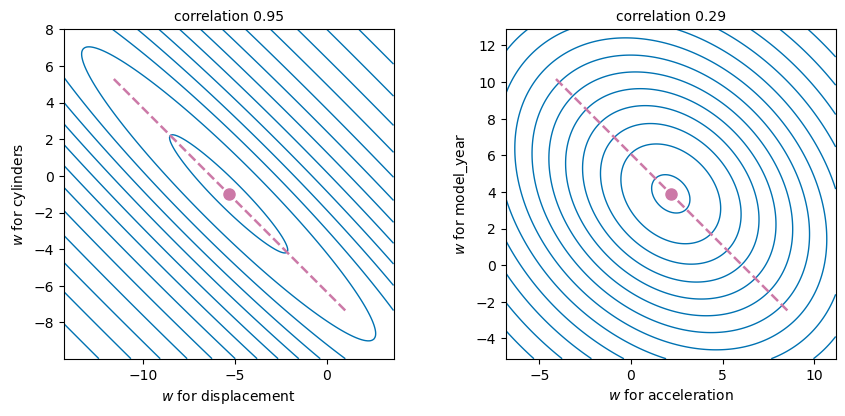

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

y_mpg = mpg['mpg'].to_numpy(float)
y_mpg = y_mpg - y_mpg.mean()          # centered, so we can drop the bias term

def loss_surface(cols, ax, title):
    X = StandardScaler().fit_transform(mpg[cols].to_numpy(float))
    w_star = LinearRegression(fit_intercept=False).fit(X, y_mpg).coef_

    span = 9
    g = np.linspace(-span, span, 220)
    W1, W2 = np.meshgrid(w_star[0] + g, w_star[1] + g)
    # mean squared error at every point of the grid
    P = X[:, 0][:, None, None] * W1 + X[:, 1][:, None, None] * W2
    Z = ((P - y_mpg[:, None, None]) ** 2).mean(axis=0)

    ax.contour(W1, W2, Z, levels=np.geomspace(Z.min() + 1, Z.max(), 14),
               colors='#0072B2', linewidths=1.0)

    # mark the flattest direction -- the floor of the valley, if there is one
    evals, evecs = np.linalg.eigh(2 * X.T @ X / len(X))
    v = evecs[:, 0] * span
    ax.plot([w_star[0] - v[0], w_star[0] + v[0]],
            [w_star[1] - v[1], w_star[1] + v[1]],
            color='#CC79A7', linewidth=1.8, linestyle='--', zorder=4)
    ax.plot(*w_star, marker='o', markersize=8, color='#CC79A7', zorder=5)
    ax.set_aspect('equal')            # essential: otherwise the shape is a lie
    ax.set_xlabel(f'$w$ for {cols[0]}')
    ax.set_ylabel(f'$w$ for {cols[1]}')
    ax.set_title(title, fontsize=10)

    return evals[-1] / evals[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
k1 = loss_surface(['displacement', 'cylinders'], axes[0], 'correlation 0.95')
k2 = loss_surface(['acceleration', 'model_year'], axes[1], 'correlation 0.29')
fig.tight_layout()

print(f"left  : kappa = {k1:6.1f}   ellipse axis ratio = sqrt(kappa) = {np.sqrt(k1):.2f}")
print(f"right : kappa = {k2:6.1f}   ellipse axis ratio = sqrt(kappa) = {np.sqrt(k2):.2f}")

The contours of a squared-error loss are always ellipses.  What changes between the two panels is
their shape.

On the right, with nearly uncorrelated features, the contours are close to circular: every direction
away from the minimum costs about the same amount of loss.  On the left, the contours are stretched
into a long narrow valley running diagonally.  Moving along the valley floor costs almost nothing;
moving across it costs a great deal.

The ratio of the long axis to the short axis is exactly $\sqrt{\kappa}$, where $\kappa$ is the
condition number of the Hessian $\frac{2}{n}\mathbf{X}^\top\mathbf{X}$.  **The condition number is
the eccentricity of the loss surface.**  A well-conditioned problem is a round bowl; an
ill-conditioned one is a narrow ravine.

Which direction is the valley floor?  It is the eigenvector of the smallest eigenvalue -- the
direction the data constrains least.  Let us look at it, and at what it costs to move along it.

In [17]:
X2 = StandardScaler().fit_transform(mpg[['displacement', 'cylinders']].to_numpy(float))
w_star = LinearRegression(fit_intercept=False).fit(X2, y_mpg).coef_
mse = lambda w: float((((X2 @ w) - y_mpg) ** 2).mean())

H = 2 * X2.T @ X2 / len(X2)
eigenvalues, eigenvectors = np.linalg.eigh(H)
v_flat = eigenvectors[:, 0]           # eigenvector of the smallest eigenvalue

print(f"flattest direction   : {np.round(v_flat, 3)}")
print(f"  i.e. add {v_flat[0]:+.2f} to the displacement coefficient and {v_flat[1]:+.2f} to the cylinder one")
print()
print(f"{'w':>28}   {'MSE':>8}")
print(f"{str(np.round(w_star, 2)):>28}   {mse(w_star):8.3f}   <- the fitted solution")
for c in (2, 5):
    print(f"{str(np.round(w_star + c*v_flat, 2)):>28}   {mse(w_star + c*v_flat):8.3f}   "
          f"<- moved {c} units along the valley floor")
print()
print("the same moves, but across the valley (steepest direction):")
v_steep = eigenvectors[:, -1]
for c in (2, 5):
    print(f"{str(np.round(w_star + c*v_steep, 2)):>28}   {mse(w_star + c*v_steep):8.3f}")

flattest direction   : [-0.707  0.707]
  i.e. add -0.71 to the displacement coefficient and +0.71 to the cylinder one

                           w        MSE
               [-5.34 -0.98]     21.282   <- the fitted solution
               [-6.76  0.43]     21.479   <- moved 2 units along the valley floor
               [-8.88  2.55]     22.511   <- moved 5 units along the valley floor

the same moves, but across the valley (steepest direction):
               [-3.93  0.43]     29.085
               [-1.81  2.55]     70.053


Moving two units along the valley floor changes the coefficients substantially -- each moves by
about 1.4, in opposite directions -- and costs only a fraction of a unit of loss.  Moving the *same
distance* across the valley costs enormously more.

That is the trade-off the data cannot resolve, in exactly the form the first notebook predicted:
more cylinders, or more displacement?  Both features say "big engine," and the training data has no
way to apportion credit between them.  The loss is nearly indifferent, so the individual coefficients are
nearly arbitrary even though their combination is well determined.

A useful way to hold this: **$\kappa$ measures how far you can move the answer without moving the
loss.**  A large $\kappa$ means the loss is a poor witness to the solution.

### What this does to gradient descent

Gradient descent has to choose a single learning rate for all directions.  To remain stable it must
use a step small enough for the *steepest* direction, since a step larger than $2/\lambda_{\max}$
diverges.  But the distance it needs to travel lies mostly along the *flattest* direction, where the
gradient is proportional to $\lambda_{\min}$ and progress is correspondingly slow.  The number of
iterations needed scales with the ratio of the two, which is $\kappa$.

In a narrow ravine, gradient descent bounces between the steep walls while creeping along the floor.

We do not need to do anything elaborate to see this.  The auto-mpg columns already span a wide range
of conditioning on their own -- it depends only on which of them we choose to include.

In [18]:
def kappa_of(cols):
    X = StandardScaler().fit_transform(mpg[cols].to_numpy(float))
    eigenvalues = np.linalg.eigvalsh(X.T @ X / len(X))
    return eigenvalues[-1] / eigenvalues[0]

# start with two nearly uncorrelated columns, then add the engine measurements one at a time
nested = ['acceleration', 'model_year', 'weight', 'displacement', 'horsepower', 'cylinders']

print(f"{'features':<52} {'p':>2} {'kappa':>8}")
for k in range(2, len(nested) + 1):
    cols = nested[:k]
    label = ', '.join(cols) if k == 2 else '+ ' + cols[-1]
    print(f"{label:<52} {k:>2} {kappa_of(cols):>8.1f}")

features                                              p    kappa
acceleration, model_year                              2      1.8
+ weight                                              3      2.9
+ displacement                                        4     45.9
+ horsepower                                          5     65.4
+ cylinders                                           6    117.0


Note where the jump happens.  Adding `weight` to the first two columns barely changes $\kappa$.
Adding `displacement` to a set that already contains `weight` multiplies it by more than fifteen
because `displacement` brings very little information that `weight` did not already carry, while
adding one more direction for the solution to be uncertain about.  *The columns that damage
conditioning are exactly the ones that are least informative.*

Now let us run the same optimizer, with the same learning rate and batch size, on a well-conditioned
pair of columns and on the badly conditioned engine features, and watch how each converges.

Before we measure gradient descent against the analytic solution, we should ask whether the analytic
solution is itself trustworthy at this conditioning.  It would be circular to use a reference that
the same ill-conditioning had corrupted.

The reassuring fact is that `LinearRegression` does not form $\mathbf{X}^\top\mathbf{X}$ and invert
it.  It solves the least-squares problem from a factorization of $\mathbf{X}$ itself, so its accuracy
is governed by $\kappa(\mathbf{X})$ -- the square root of the number we have been quoting.  Let us
check by solving the same problem four different ways.

In [38]:
def compare_solvers(cols):
    X = StandardScaler().fit_transform(mpg[cols].to_numpy(float))

    solutions = {
        'LinearRegression': LinearRegression(fit_intercept=False).fit(X, y_mpg).coef_,
        'numpy lstsq (SVD)': np.linalg.lstsq(X, y_mpg, rcond=None)[0],
        'normal equations': np.linalg.solve(X.T @ X, X.T @ y_mpg),
    }
    reference = solutions['numpy lstsq (SVD)']

    print(f"{cols}")
    print(f"   kappa(X'X) = {kappa_of(cols):8.1f}      kappa(X) = {np.linalg.cond(X):6.2f}")
    for name, w in solutions.items():
        gap = np.linalg.norm(w - reference) / np.linalg.norm(reference)
        print(f"   {name:<20} differs from the SVD solution by {gap:.1e}")
    print()

compare_solvers(['acceleration', 'model_year'])
compare_solvers(['cylinders', 'displacement', 'horsepower', 'weight'])

['acceleration', 'model_year']
   kappa(X'X) =      1.8      kappa(X) =   1.35
   LinearRegression     differs from the SVD solution by 0.0e+00
   numpy lstsq (SVD)    differs from the SVD solution by 0.0e+00
   normal equations     differs from the SVD solution by 1.9e-15

['cylinders', 'displacement', 'horsepower', 'weight']
   kappa(X'X) =    100.6      kappa(X) =  10.03
   LinearRegression     differs from the SVD solution by 0.0e+00
   numpy lstsq (SVD)    differs from the SVD solution by 0.0e+00
   normal equations     differs from the SVD solution by 3.9e-15



All methods agree to about fifteen significant digits, including the normal equations, which are the
least accurate route.  The condition number needs to be much larger for it to become a problem for these solvers.

In [20]:
import torch
from torch import nn

def track_convergence(cols, checkpoints, lr=0.01, batch_size=32, seed=0):
    X = StandardScaler().fit_transform(mpg[cols].to_numpy(float))
    w_exact = np.linalg.lstsq(X, y_mpg, rcond=None)[0]
    mse_exact = float(((X @ w_exact - y_mpg) ** 2).mean())

    torch.manual_seed(seed)
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y_mpg, dtype=torch.float32).reshape(-1, 1)
    model, loss_fn = nn.Linear(X.shape[1], 1, bias=False), nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    print(f"{cols}   kappa = {kappa_of(cols):.1f}")
    print(f"   {'epoch':>6} {'MSE gap':>9} {'||w-w*||/||w*||':>17}   coefficients")
    for epoch in range(1, max(checkpoints) + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimizer.step()
        if epoch in checkpoints:
            w = model.weight.detach().numpy().ravel()
            mse = float(((X @ w - y_mpg) ** 2).mean())
            distance = np.linalg.norm(w - w_exact) / np.linalg.norm(w_exact)
            print(f"   {epoch:>6} {mse - mse_exact:>9.4f} {distance:>17.3f}   "
                  f"{np.array2string(w, precision=3)}")
    print(f"   {'exact':>6} {0.0:>9.4f} {0.0:>17.3f}   {np.array2string(w_exact, precision=3)}")
    print()

CHECKPOINTS = (1, 5, 20, 100, 400)
track_convergence(['acceleration', 'model_year'], CHECKPOINTS)
track_convergence(['cylinders', 'displacement', 'horsepower', 'weight'], CHECKPOINTS)

['acceleration', 'model_year']   kappa = 1.8
    epoch   MSE gap   ||w-w*||/||w*||   coefficients
        1   11.2441             0.673   [0.688 1.286]
        5    0.6218             0.170   [2.056 3.147]
       20    0.0090             0.019   [2.105 3.842]
      100    0.0015             0.010   [2.141 3.933]
      400    0.0115             0.023   [2.07  3.875]
    exact    0.0000             0.000   [2.169 3.896]

['cylinders', 'displacement', 'horsepower', 'weight']   kappa = 100.6
    epoch   MSE gap   ||w-w*||/||w*||   coefficients
        1    5.7298             0.660   [-0.957 -0.716 -1.363 -1.411]
        5    0.6584             0.559   [-1.408 -1.244 -1.897 -2.227]
       20    0.3325             0.396   [-1.025 -0.97  -1.718 -2.885]
      100    0.0140             0.108   [-0.603 -0.409 -1.543 -4.205]
      400    0.0020             0.014   [-0.675  0.022 -1.625 -4.54 ]
    exact    0.0000             0.000   [-0.67   0.015 -1.646 -4.477]



The middle column is $\|\mathbf{w} - \mathbf{w}^*\| / \|\mathbf{w}^*\|$, the distance from the
analytic solution measured relative to its length.

Compare the two tables at the point where each *looks* converged.

For the well-conditioned pair, the loss and the coefficients arrive together.  By epoch 20 the loss
is within 0.009 of optimal and the coefficients read $(2.105, 3.842)$ against an exact
$(2.169, 3.896)$, correct to about two decimal places in each.

For the higher condition number version of the dataset, at epoch 20 the MSE gap is 0.33 out of a loss of about 17.8 which is under 2%, which you might call as having converged. And yet, the weights are far from the optimal solution.  The weight on `displacement` has the **wrong sign**, and the one on `weight` is short by more than a third.  Look at *how* it is wrong: gradient descent has put weight and displacement on a roughly equal footing, while the analytic solution assigns almost everything to `weight` and almost nothing to `displacement`.  That is the flat direction from the loss landscape being traversed slowly.  The two collinear columns are trading credit, exactly as the valley picture predicted, and the sum of their contributions is close to right the whole time.

**Agreement in the loss is not agreement in the solution.**  This is worth pausing on, because the
loss curve is the diagnostic we habitually reach for, and on an ill-conditioned problem does not give us the complete picture.

Gradient descent got there in the end, in both cases.  At these condition numbers ill-conditioning costs iterations rather than correctness -- about twenty times as
many here for comparable accuracy.  That is the typical situation, and it is why one of the remedies
discussed under training methods is an optimizer that handles ravines better.  In the previous
notebook the coefficients and the loss agreed from the start; now we know why -- $\kappa$ was close
to 1, so there was no ravine to creep along.

### Where this goes

We have a diagnosis but not yet a cure.  Three responses to ill-conditioning appear later in the
course, and it is worth naming them now:

* **Change the problem.**  Adding a penalty on $\|\mathbf{w}\|^2$ raises every eigenvalue of the
  Hessian by the same amount, which lifts the valley floor and lowers $\kappa$ directly.  This is
  ridge regression, and we take it up in the notebook on weight decay.
* **Change the optimizer.**  Momentum accumulates progress along the consistent direction -- the
  valley floor -- while damping the oscillation across the ravine, improving the dependence on
  $\kappa$ to $\sqrt{\kappa}$.  We return to this when we discuss training methods.
* **Change the features.**  If two columns measure the same physical quantity, we can drop one, or
  replace both with something better posed.  The exploratory work of noticing such redundancies is a
  large part of what feature engineering is for.

## Summary

This notebook is our first implementation of a deep network to tap into the conveniences afforded by modern deep learning frameworks such as PyTorch.
We used PyTorch functionality for loading data, defining a layer,
a loss function, an optimizer and a training loop.
Whenever the framework provides all necessary features,
it is generally a good idea to use them,
since the library implementations of these components
tend to be heavily optimized for performance
and properly tested for reliability.
At the same time, try not to forget
that these modules *can* be implemented directly.
This is especially important for aspiring researchers
who wish to live on the leading edge of model development,
where you will be inventing new components
that do not exist in any current library.


## Exercises

1. The Huber robust loss function is an alternative to the squared error loss function. It is defined as:
   $$l(y,y') = \begin{cases}|y-y'| -\frac{\delta}{2} & \textrm{ if } |y-y'| > \delta \\ \frac{1}{2 \delta} (y-y')^2 & \textrm{ otherwise}\end{cases}$$
   Replace `nn.MSELoss` with PyTorch's built-in Huber loss (`nn.HuberLoss`),  and retrain. How does the learned solution change, and how does it respond if you add a few large outliers to the training targets?
2. How do you access the gradient of the weights of the model?
3. What is the effect on the solution if you change the learning rate and the number of epochs?